### QED-C Application-Oriented Benchmarks - Pre-defined Equal1-Runner

Using Qiskit to construct and run benchmarks, but inserting in Equal1 way of executing. 

## Default configurations
Change the following values to control benchmark parameters

In [1]:
# Generic becnhmark paramters
min_qubits = 2
max_qubits = 17
skip_qubits = 1
max_circuits = 2
num_shots = 1000

# Equal1 device specific
equal1_device = "equal1_simulator"
equal1_noise_model = "bell2-17-gen-preview"

Setup equal1 execution environment

In [ ]:
import base64

from qbraid import QbraidProvider
from qiskit import QuantumCircuit, qasm2


class QBraidBackEnd():
    def __init__(self):
        self.name = "QBraidEqual1Backend"

class QBraidResult:
    def __init__(self, counts, exec_time, transpiled_circuit_metrics):
        self.exec_time = exec_time
        self.counts = counts
        self.transpiled_circuit_metrics = transpiled_circuit_metrics

    def get_counts(self, qc):
        return self.counts

    def get_transpiled_circuit_metrics(self):
        return self.transpiled_circuit_metrics

class QBraidExecutor():
    def __init__(self):
        provider = QbraidProvider()
        self.device = provider.get_device("equal1_simulator")

    def __call__(self, qc : QuantumCircuit, backend_name : str, backend, shots, **kwargs) -> QBraidResult:
        # print(f"attempting to run {qc} on {backend_name}, on {backend} with {shots} and {kwargs}")

        runtime_options = {
            "simulation_platform": "GPU",
            "execution_options": {"optimization_level": 2},
        }

        backend = "StateVector" if qc.num_qubits > 8 else "DensityMatrix"

        job = self.device.run(qc, shots=shots, noise_model="bell2-17-gen-preview", runtime_options=runtime_options, backend=backend)
        job.wait_for_final_state()  # Wait for the job to complete and get final state

        if job.status().name != "COMPLETED":
            job_result = job.client.get_job_results(job.id)
            print(f"\n@@@@@@@@@@@@@@ \n JOB FAILED for {qc} \n With error message:\n {job_result['statusText']}\n @@@@@@@@@@@@@@@@@@ \n ")


        result = job.result()
        counts = result.data.get_counts()
        # print(counts)

        result_json = job.client.get_job_results(job.id)
        inner_exec_time = result_json['executionMetrics']['executor']


        transpiled_circuit = base64.b64decode(result_json['compiledOutput']).decode('utf-8')
        transpiled_qc = qasm2.loads(transpiled_circuit, custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS)

        from _common.qiskit.execute import get_circuit_metrics
        metrics = get_circuit_metrics(transpiled_qc)


        return QBraidResult(counts, inner_exec_time, metrics)



In [3]:
# Common setup parameters
backend_id = "qasm_simulator"

hub = ""
group = ""
project = ""
provider_backend = None

exec_options = {
    "executor" : QBraidExecutor()
}


/home/iszilveszter/work/cuda-quantum/QC-App-Oriented-Benchmarks/.venv/lib/python3.12/site-packages/qbraid/runtime/native/provider.py:151: RuntimeWarning: The default runtime configuration for device 'equal1_simulator' includes transpilation to program type 'cudaq', which is not registered.
  warnings.warn(


### Deutsch-Jozsa

Deutsch-Jozsa Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 16:19:31 UTC
************
Executing [2] circuits with num_qubits = 3
************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 7, 0.083
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 12, 0.037, 1.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.0, 12.868, 0.042 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.953, 0.937

************
Executing [2] circuits with num_qubits = 5
************
Executing [2] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 8, 0.088
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 12, 0.042, 1.5
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.0, 23.17, 0.049 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.

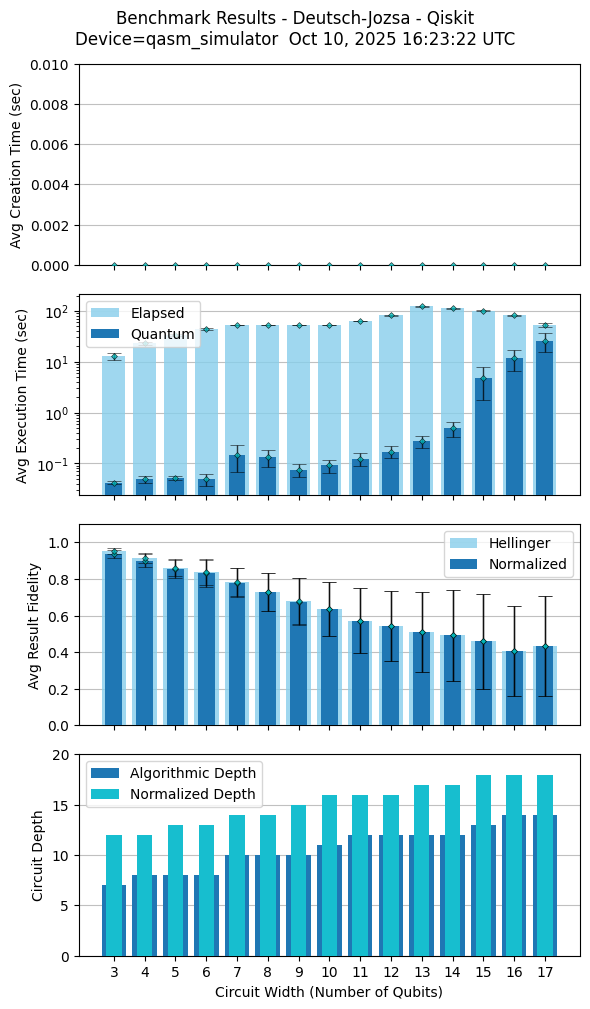

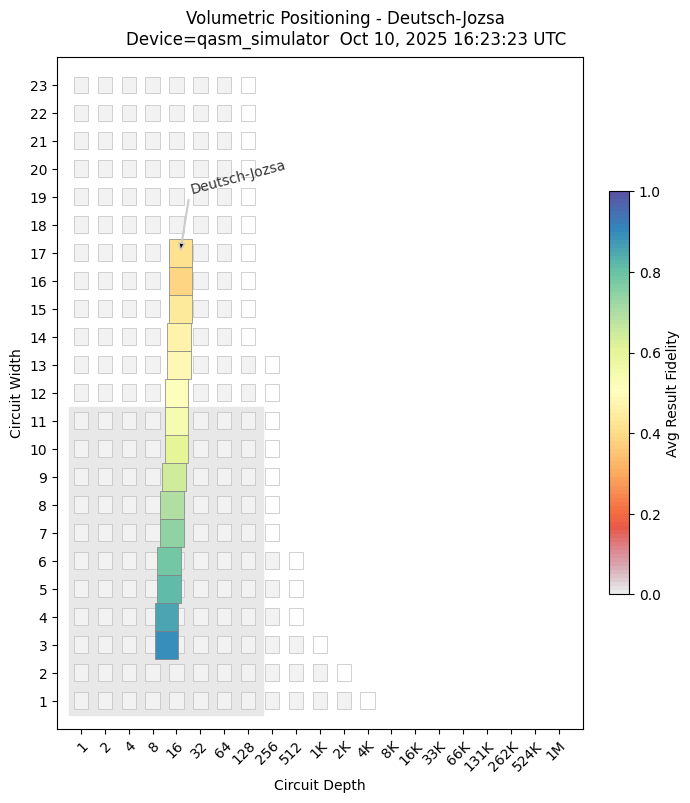

In [4]:
import sys
sys.path.insert(1, "deutsch-jozsa/qiskit")
import dj_benchmark
dj_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Bernstein-Vazirani - Method 1

Bernstein-Vazirani (1) Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 14:02:49 UTC
************
Executing [2] circuits with num_qubits = 3


************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 6, 0.111
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 13, 0.042, 1.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.001, 14.677, 0.063 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.94, 0.921

************
Executing [2] circuits with num_qubits = 5


************
Executing [2] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 6, 0.129
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 14, 0.049, 1.5
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.001, 26.663, 0.051 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.904, 0.891

************
Executing [2] circuits with num_qubits = 7
************
Executing [2] circuits with num_qubits = 8
************
Average Circuit Algorithmic Depth, ξ (xi) for the 5 qubit group = 6, 0.11
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 5 qubit group = 14, 0.041, 1.5
Average Creation, Elapsed, Execution Time for the 5 qubit group = 0.001, 39.082, 0.047 secs
Average Hellinger, Normalized Fidelity for the 5 qubit group = 0.876, 0.868

************
Executing [2] circuits with num_qubits = 9
************
Executing [2] circuits with num_qubits = 10
************
Average

************
Average Circuit Algorithmic Depth, ξ (xi) for the 12 qubit group = 12, 0.198
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 12 qubit group = 18, 0.078, 6.5
Average Creation, Elapsed, Execution Time for the 12 qubit group = 0.001, 67.886, 0.127 secs
Average Hellinger, Normalized Fidelity for the 12 qubit group = 0.36, 0.36

************
Average Circuit Algorithmic Depth, ξ (xi) for the 13 qubit group = 10, 0.138
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 13 qubit group = 16, 0.051, 4.5
Average Creation, Elapsed, Execution Time for the 13 qubit group = 0.001, 77.396, 0.16 secs
Average Hellinger, Normalized Fidelity for the 13 qubit group = 0.407, 0.407

************
Average Circuit Algorithmic Depth, ξ (xi) for the 14 qubit group = 10, 0.142
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 14 qubit group = 17, 0.053, 5.0
Average Creation, Elapsed, Execution Time for the 14 qubit group = 0.001, 65.189, 0.291 secs
Average Hellinge

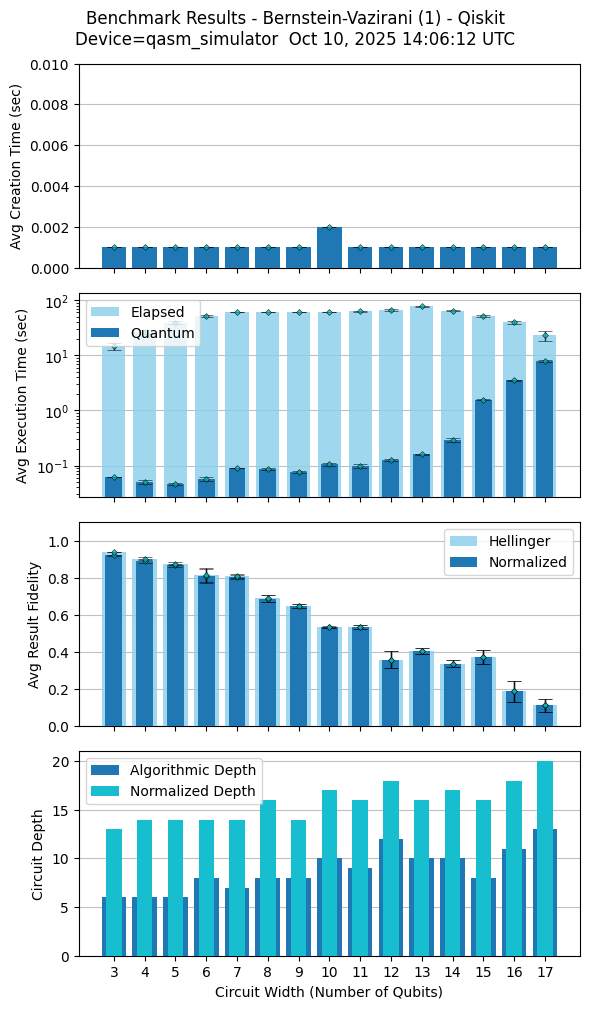

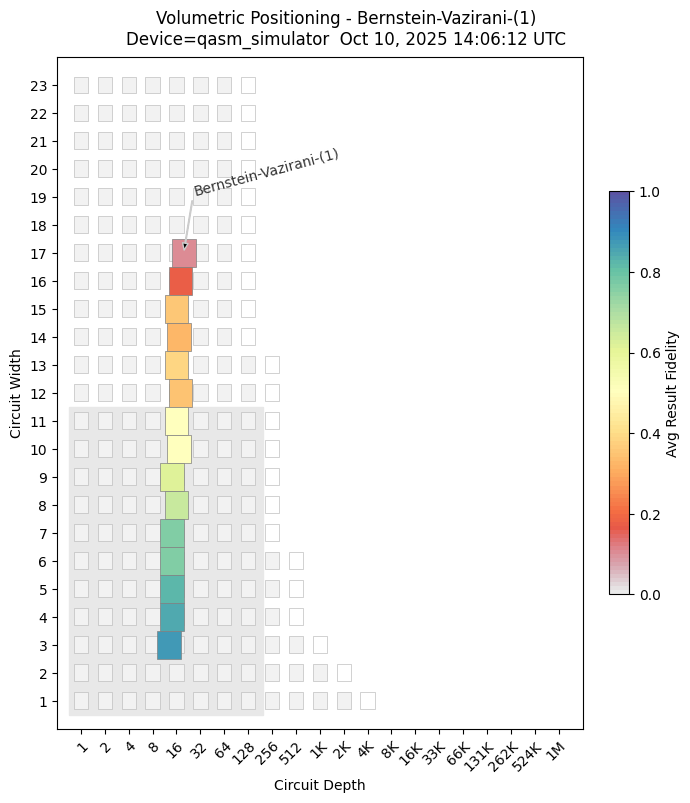

In [16]:
import sys
sys.path.insert(1, "bernstein-vazirani")
import bv_benchmark
bv_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hidden Shift

Hidden Shift Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 14:15:59 UTC
************
Executing [2] circuits with num_qubits = 2


************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 8, 0.2
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 14, 0.091, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 15.237, 0.048 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.937, 0.916

************
Executing [2] circuits with num_qubits = 6
************
Executing [2] circuits with num_qubits = 8


************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 8, 0.211
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 14, 0.093, 4.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.001, 28.256, 0.06 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.87, 0.862

************
Executing [2] circuits with num_qubits = 10


************
Executing [2] circuits with num_qubits = 12
************
Average Circuit Algorithmic Depth, ξ (xi) for the 6 qubit group = 8, 0.223
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 6 qubit group = 14, 0.095, 6.0
Average Creation, Elapsed, Execution Time for the 6 qubit group = 0.001, 41.539, 0.061 secs
Average Hellinger, Normalized Fidelity for the 6 qubit group = 0.801, 0.798

************
Executing [2] circuits with num_qubits = 14
************
Executing [2] circuits with num_qubits = 16
************
Average Circuit Algorithmic Depth, ξ (xi) for the 8 qubit group = 8, 0.229
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 8 qubit group = 14, 0.096, 8.0
Average Creation, Elapsed, Execution Time for the 8 qubit group = 0.001, 54.816, 0.084 secs
Average Hellinger, Normalized Fidelity for the 8 qubit group = 0.73, 0.729

************
Average Circuit Algorithmic Depth, ξ (xi) for the 10 qubit group = 8, 0.222
Average Normalized Transpiled Depth, ξ (x

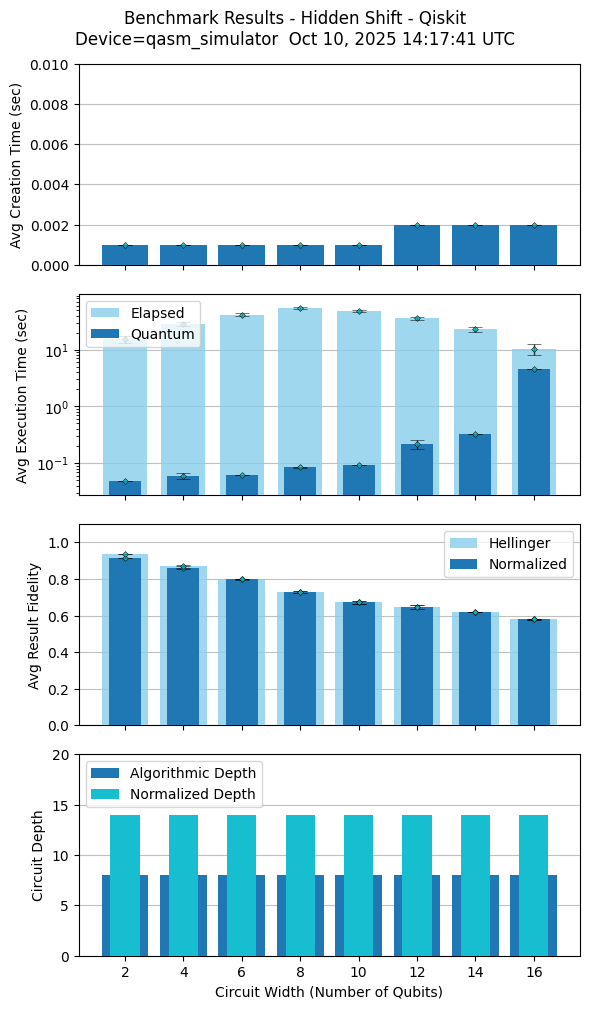

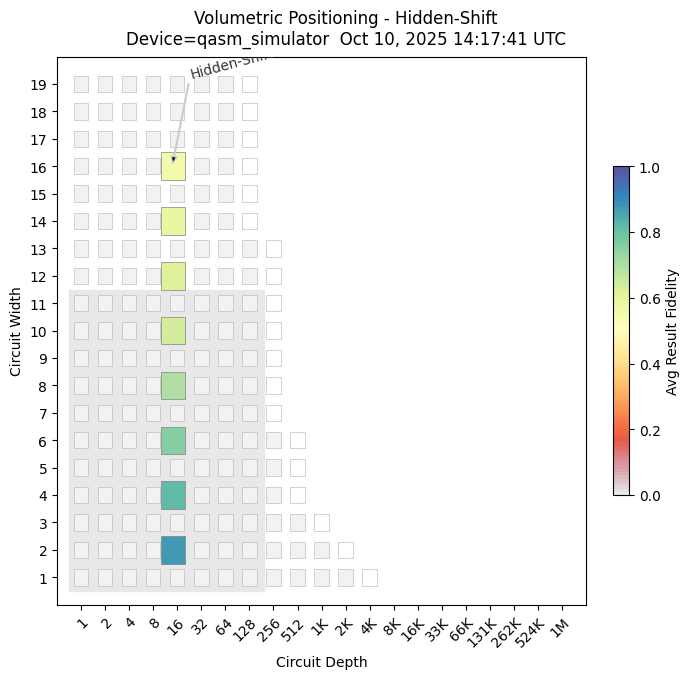

In [17]:
import sys
sys.path.insert(1, "hidden-shift")
import hs_benchmark
hs_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Grover

In [35]:
import sys
sys.path.insert(1, "grovers/qiskit")
import grovers_benchmark

grover_max_circuits = 8 if max_circuits > 8 else max_circuits
grovers_benchmark.run(min_qubits=8, max_qubits=8, skip_qubits=skip_qubits,
                max_circuits=grover_max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

Grover's Search Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 16:17:39 UTC
************
Executing [2] circuits with num_qubits = 8


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f906a3c13a0>>
Traceback (most recent call last):
  File "/home/iszilveszter/work/cuda-quantum/QC-App-Oriented-Benchmarks/.venv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

### Phase Estimation

Phase Estimation Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 15:23:51 UTC
************
Executing [2] circuits with num_qubits = 3


************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 16, 0.316
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 26, 0.112, 4.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.004, 15.514, 0.099 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.884, 0.845

************
Executing [2] circuits with num_qubits = 5
************
Executing [2] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 27, 0.353
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 52, 0.14, 10.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.005, 28.71, 0.187 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.745, 0.709

************
Executing [2] circuits with num_qubits = 7
************
Executing [2] circuits with num_qubits = 8
************
Averag

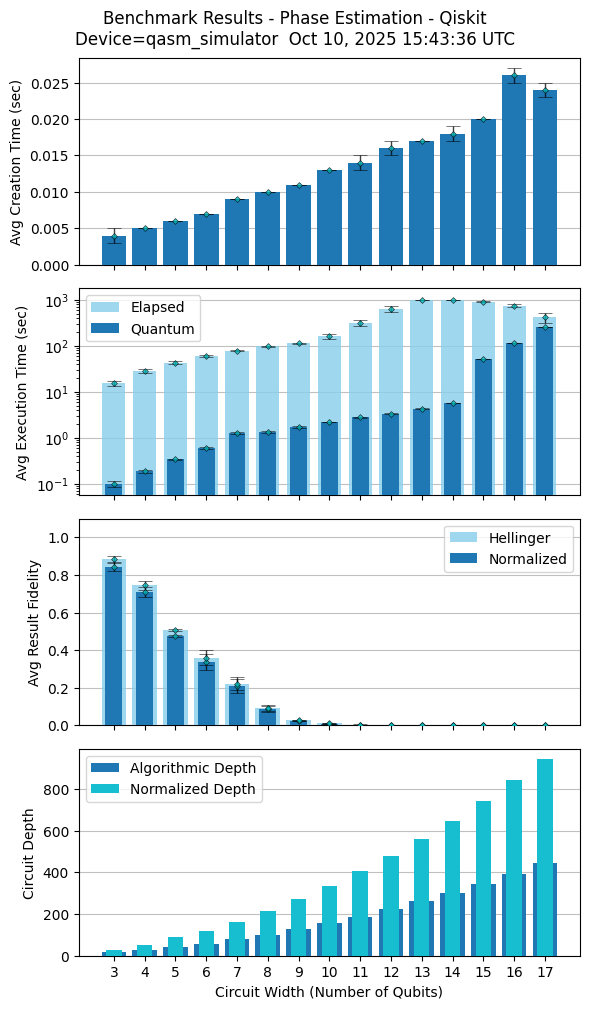

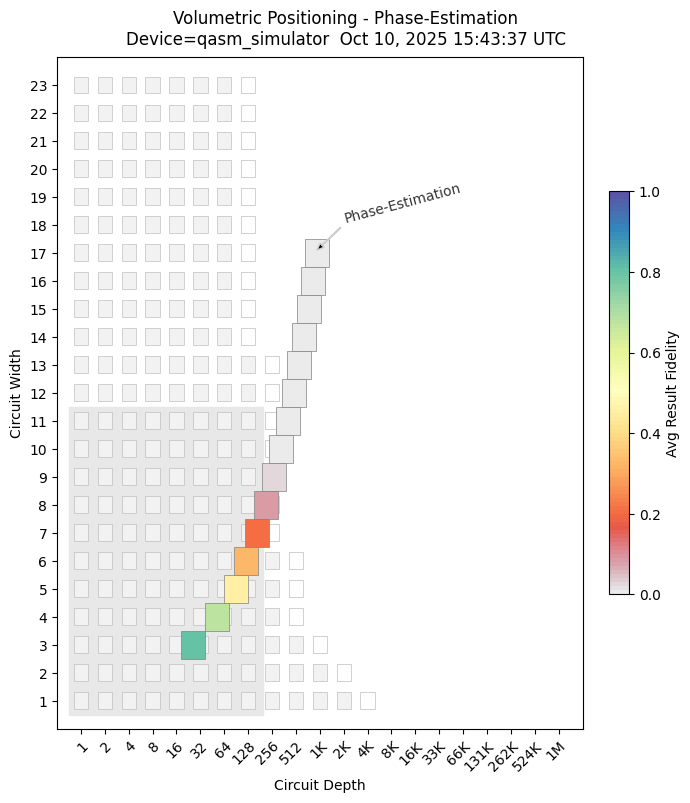

In [21]:
import sys
sys.path.insert(1, "phase-estimation")
import pe_benchmark
pe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### HHL Linear Solver

In [ ]:
import sys
sys.path.insert(1, "hhl/qiskit")
import hhl_benchmark

hhl_benchmark.verbose=False

hhl_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1, use_best_widths=True,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Amplitude Estimation

In [ ]:
import sys
sys.path.insert(1, "amplitude-estimation/qiskit")


import ae_benchmark
ae_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)



### Monte Carlo

Monte Carlo Sampling (2) Benchmark Program - Qiskit
INFO: Monte Carlo Sampling benchmark is limited to a maximum of 10 qubits.
... execution starting at Oct 10, 2025 06:09:29 UTC
************
Executing [2] circuits with num_qubits = 4
************
Executing [2] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 199, 0.352
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 278, 0.172, 72.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.008, 150.905, 1.252 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.509, 0.018

************
Executing [2] circuits with num_qubits = 6
************
Executing [2] circuits with num_qubits = 7


************
Average Circuit Algorithmic Depth, ξ (xi) for the 5 qubit group = 461, 0.354
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 5 qubit group = 631, 0.176, 168.0
Average Creation, Elapsed, Execution Time for the 5 qubit group = 0.01, 400.169, 3.857 secs
Average Hellinger, Normalized Fidelity for the 5 qubit group = 0.249, 0.006

************
Executing [2] circuits with num_qubits = 8


************
Executing [2] circuits with num_qubits = 9


ERROR: Failed to execute circuit 9 0.6171875
... exception = Failed to retrieve job data: HTTPConnectionPool(host='localhost', port=62123): Max retries exceeded with url: /quantum-jobs?qbraidJobId=88471edb-1a9d-4c5f-b192-c61235df2605 (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fca483fafc0>: Failed to establish a new connection: [Errno 111] Connection refused')).


ERROR: Failed to execute circuit 9 0.32421875
... exception = Failed to retrieve device data: HTTPConnectionPool(host='localhost', port=62123): Max retries exceeded with url: /quantum-devices?qbraid_id=equal1_simulator (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fca3a8f2990>: Failed to establish a new connection: [Errno 111] Connection refused')).
************
Average Circuit Algorithmic Depth, ξ (xi) for the 6 qubit group = 982, 0.354
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 6 qubit group = 1322, 0.178, 358.0
Average Creation, Elapsed, Execution Time for the 6 qubit group = 0.014, 1524.055, 7.514 secs
Average Hellinger, Normalized Fidelity for the 6 qubit group = 0.115, 0.0

************
Executing [2] circuits with num_qubits = 10


ERROR: Failed to execute circuit 10 0.552734375
... exception = Failed to retrieve device data: HTTPConnectionPool(host='localhost', port=62123): Max retries exceeded with url: /quantum-devices?qbraid_id=equal1_simulator (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fca484bcbf0>: Failed to establish a new connection: [Errno 111] Connection refused')).


ERROR: Failed to execute circuit 10 0.1953125
... exception = Failed to retrieve device data: HTTPConnectionPool(host='localhost', port=62123): Max retries exceeded with url: /quantum-devices?qbraid_id=equal1_simulator (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fca493531d0>: Failed to establish a new connection: [Errno 111] Connection refused')).
************
Average Circuit Algorithmic Depth, ξ (xi) for the 7 qubit group = 2018, 0.355
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 7 qubit group = 2692, 0.179, 734.0
Average Creation, Elapsed, Execution Time for the 7 qubit group = 0.026, 1451.629, 27.027 secs
Average Hellinger, Normalized Fidelity for the 7 qubit group = 0.047, 0.0

************
Average Circuit Algorithmic Depth, ξ (xi) for the 8 qubit group = 4081, 0.355
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 8 qubit group = 5413, 0.18, 1480.0
Average Creation, Elapsed, Execution Time for the 8 qubit group = 0.0

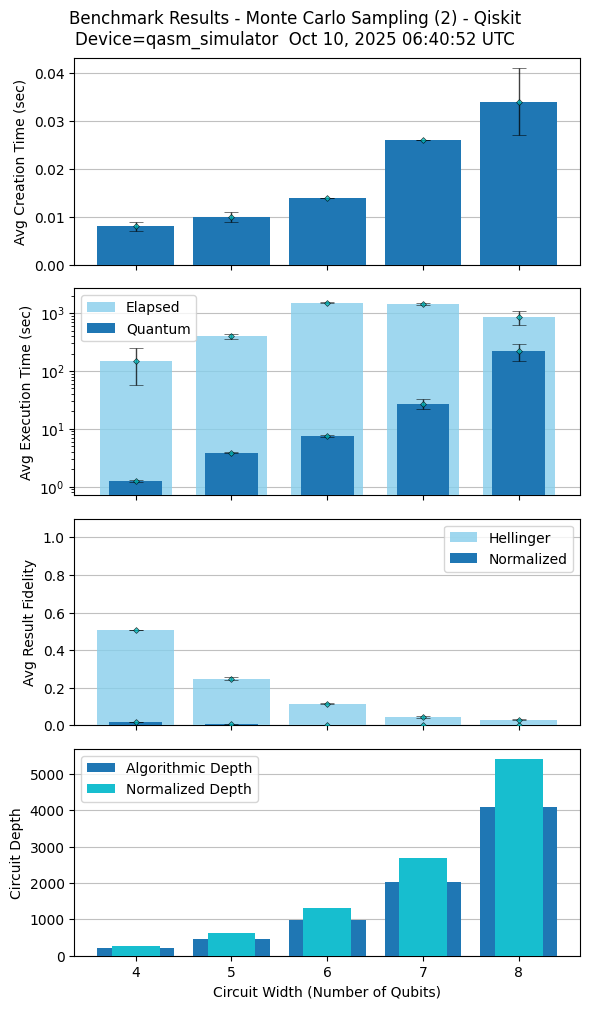

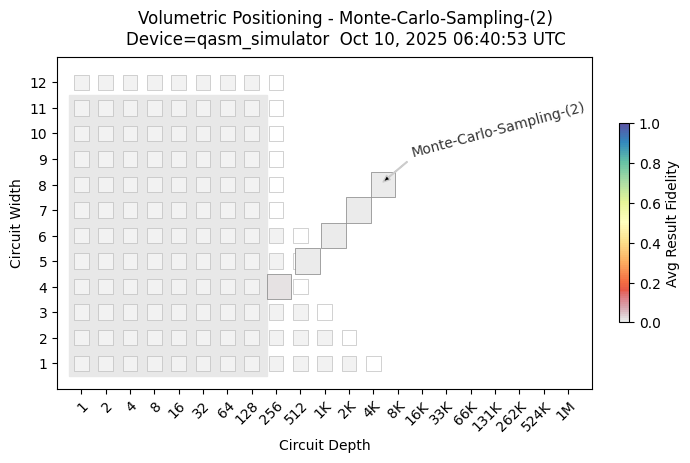

In [5]:
import sys
sys.path.insert(1, "monte-carlo/qiskit")
import mc_benchmark
mc_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hamiltonian Simulation - Method 1 

In [ ]:
import sys
sys.path.insert(1, "hamiltonian-simulation/qiskit")
import hamiltonian_simulation_benchmark
hamiltonian_simulation_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hamiltonian Simulation - Method 2 

In [ ]:
import sys
sys.path.insert(1, "hamiltonian-simulation/qiskit")
import hamiltonian_simulation_benchmark
hamiltonian_simulation_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### VQE - Method 1

In [ ]:
import sys
sys.path.insert(1, "vqe/qiskit")
import vqe_benchmark
vqe_num_shots=4098
vqe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits,
                max_circuits=max_circuits, num_shots=vqe_num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Shor - Method 1

In [ ]:
import sys
sys.path.insert(1, "shors/qiskit")
import shors_benchmark
shors_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=1, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Shor - Method 2

In [ ]:
import sys
sys.path.insert(1, "shors/qiskit")
import shors_benchmark
shors_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=1, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Quantum Fourier Transform - Method 1

Quantum Fourier Transform (1) Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 14:18:31 UTC
************
Executing [2] circuits with num_qubits = 2


************
Executing [2] circuits with num_qubits = 3


************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 9, 0.222
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 30, 0.114, 4.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.002, 14.902, 0.101 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.933, 0.911

************
Executing [2] circuits with num_qubits = 4
************
Executing [2] circuits with num_qubits = 5


************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 15, 0.375
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 62, 0.146, 12.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.001, 27.08, 0.292 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.786, 0.755

************
Executing [2] circuits with num_qubits = 6
************
Executing [2] circuits with num_qubits = 7
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 23, 0.48
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 105, 0.161, 24.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.001, 40.971, 0.455 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.594, 0.567

************
Executing [2] circuits with num_qubits = 8
************
Executing [2] circuits with num_qubits = 9
************
Average Circuit Algorithmic Depth, ξ (xi) for the 5 qubit gr

************
Average Circuit Algorithmic Depth, ξ (xi) for the 11 qubit group = 135, 0.743
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 11 qubit group = 714, 0.186, 220.0
Average Creation, Elapsed, Execution Time for the 11 qubit group = 0.002, 548.898, 4.831 secs
Average Hellinger, Normalized Fidelity for the 11 qubit group = 0.002, 0.001

************
Executing [2] circuits with num_qubits = 17
************
Average Circuit Algorithmic Depth, ξ (xi) for the 12 qubit group = 159, 0.761
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 12 qubit group = 845, 0.187, 264.0
Average Creation, Elapsed, Execution Time for the 12 qubit group = 0.002, 1143.253, 6.06 secs
Average Hellinger, Normalized Fidelity for the 12 qubit group = 0.0, 0.0



************
Average Circuit Algorithmic Depth, ξ (xi) for the 13 qubit group = 185, 0.77
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 13 qubit group = 987, 0.188, 312.0
Average Creation, Elapsed, Execution Time for the 13 qubit group = 0.002, 1877.823, 7.745 secs
Average Hellinger, Normalized Fidelity for the 13 qubit group = 0.0, 0.0

************
Average Circuit Algorithmic Depth, ξ (xi) for the 14 qubit group = 213, 0.784
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 14 qubit group = 1140, 0.189, 364.0
Average Creation, Elapsed, Execution Time for the 14 qubit group = 0.002, 1825.495, 10.751 secs
Average Hellinger, Normalized Fidelity for the 14 qubit group = 0.0, 0.0

************
Average Circuit Algorithmic Depth, ξ (xi) for the 15 qubit group = 243, 0.795
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 15 qubit group = 1304, 0.19, 420.0
Average Creation, Elapsed, Execution Time for the 15 qubit group = 0.003, 1716.652, 98.44 secs
Av

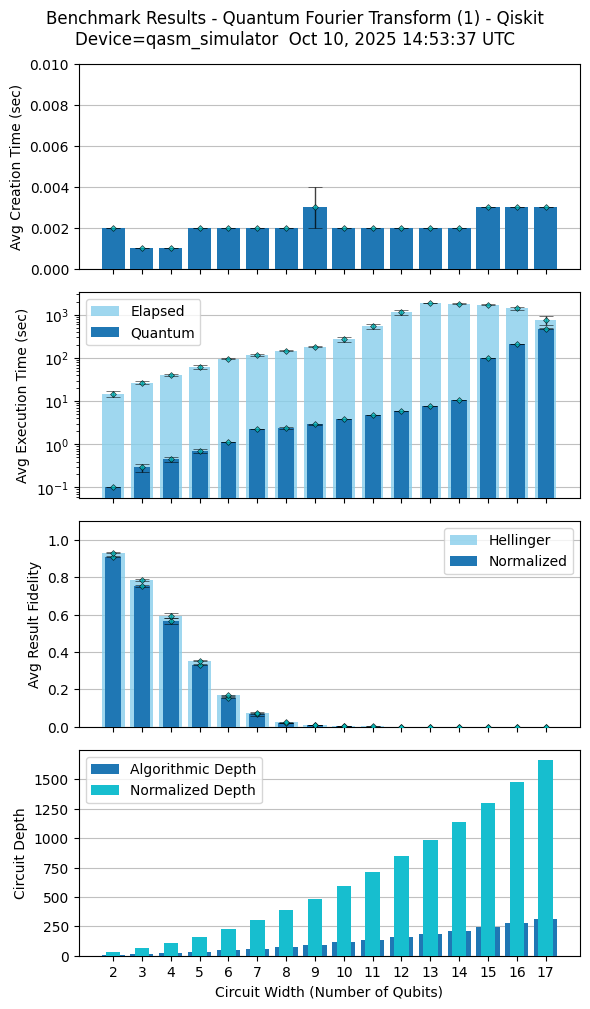

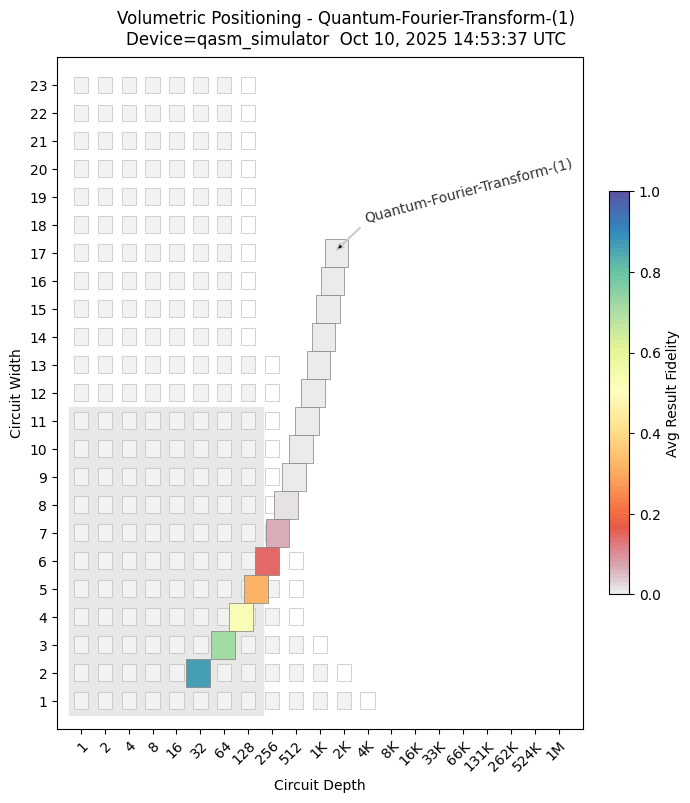

In [18]:
import sys
sys.path.insert(1, "quantum-fourier-transform")
import qft_benchmark
qft_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Quantum Fourier Transform - Method 2

Quantum Fourier Transform (2) Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 14:56:17 UTC
************
Executing [2] circuits with num_qubits = 2


************
Executing [2] circuits with num_qubits = 3


************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 6, 0.143
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 15, 0.114, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 15.384, 0.056 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.953, 0.937

************
Executing [2] circuits with num_qubits = 4
************
Executing [2] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 9, 0.25
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 32, 0.13, 6.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.001, 26.81, 0.112 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.861, 0.841

************
Executing [2] circuits with num_qubits = 6


************
Executing [2] circuits with num_qubits = 7


************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 13, 0.333
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 54, 0.141, 12.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.001, 39.532, 0.318 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.699, 0.678

************
Executing [2] circuits with num_qubits = 8
************
Executing [2] circuits with num_qubits = 9
************
Average Circuit Algorithmic Depth, ξ (xi) for the 5 qubit group = 18, 0.4
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 5 qubit group = 84, 0.147, 20.0
Average Creation, Elapsed, Execution Time for the 5 qubit group = 0.001, 53.569, 0.301 secs
Average Hellinger, Normalized Fidelity for the 5 qubit group = 0.495, 0.478

************
Executing [2] circuits with num_qubits = 10
************
Executing [2] circuits with num_qubits = 11
************
Average Circuit Algorithmic Depth, ξ (xi) for the 6 qubit g

************
Average Circuit Algorithmic Depth, ξ (xi) for the 9 qubit group = 48, 0.571
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 9 qubit group = 260, 0.16, 72.0
Average Creation, Elapsed, Execution Time for the 9 qubit group = 0.001, 103.32, 1.523 secs
Average Hellinger, Normalized Fidelity for the 9 qubit group = 0.032, 0.03



************
Executing [2] circuits with num_qubits = 15
************
Average Circuit Algorithmic Depth, ξ (xi) for the 10 qubit group = 58, 0.6
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 10 qubit group = 317, 0.163, 90.0
Average Creation, Elapsed, Execution Time for the 10 qubit group = 0.001, 145.011, 1.896 secs
Average Hellinger, Normalized Fidelity for the 10 qubit group = 0.014, 0.013

************
Executing [2] circuits with num_qubits = 16
************
Average Circuit Algorithmic Depth, ξ (xi) for the 11 qubit group = 69, 0.625
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 11 qubit group = 382, 0.165, 110.0
Average Creation, Elapsed, Execution Time for the 11 qubit group = 0.002, 296.378, 2.523 secs
Average Hellinger, Normalized Fidelity for the 11 qubit group = 0.002, 0.002

************
Executing [2] circuits with num_qubits = 17
************
Average Circuit Algorithmic Depth, ξ (xi) for the 12 qubit group = 81, 0.647
Average Normalized Trans

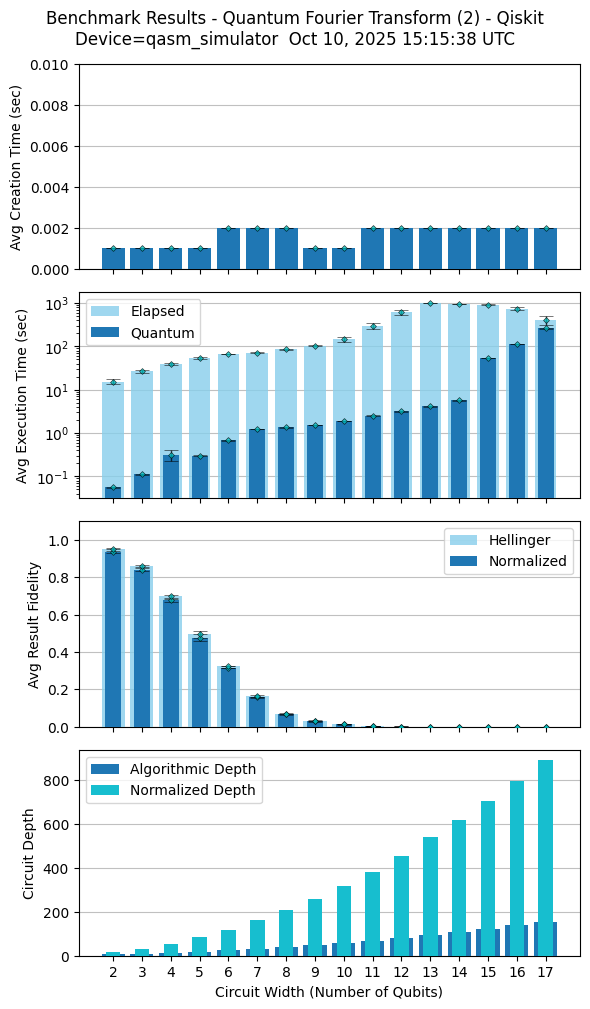

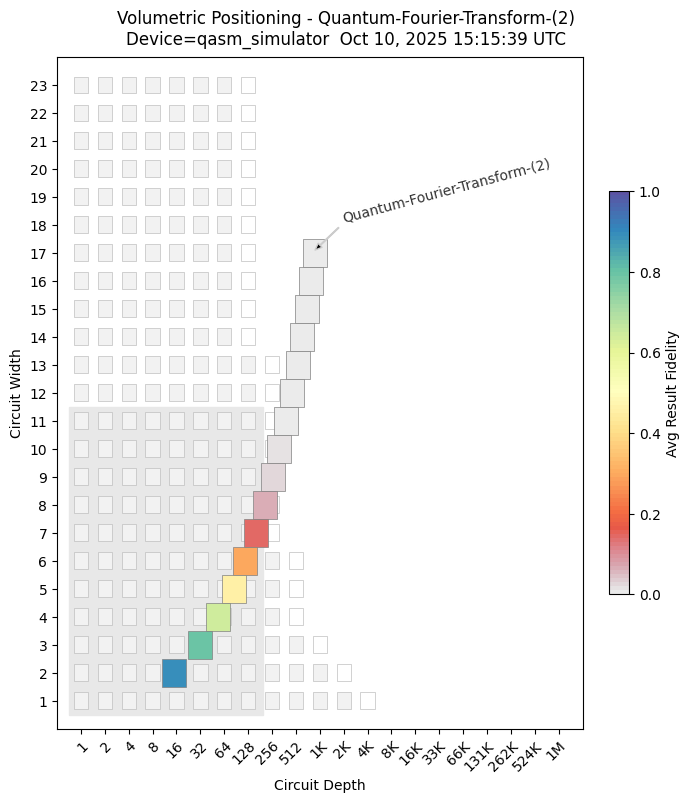

In [20]:
import sys
sys.path.insert(1, "quantum-fourier-transform")
import qft_benchmark
qft_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Bernstein-Vazirani - Method 2

In [19]:
import sys
sys.path.insert(1, "bernstein-vazirani")
import bv_benchmark
bv_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

Bernstein-Vazirani (2) Benchmark Program - Qiskit
... execution starting at Oct 10, 2025 14:54:34 UTC
************
Executing [2] circuits with num_qubits = 3

@@@@@@@@@@@@@@ 
 JOB FAILED for                                    ░ ┌────────────┐     ┌────────────┐┌─┐     »
q234_0: ───────────────────────────░─┤ U(π/2,0,π) ├──■──┤ U(π/2,0,π) ├┤M├─|0>─»
        ┌──────────┐┌────────────┐ ░ └────────────┘┌─┴─┐└────────────┘└╥┘     »
q234_1: ┤ U(π,0,π) ├┤ U(π/2,0,π) ├─░───────────────┤ X ├───────────────╫──────»
        └──────────┘└────────────┘ ░               └───┘               ║      »
 c76: 2/═══════════════════════════════════════════════════════════════╩══════»
                                                                       0      »
«        ┌─┐     
«q234_0: ┤M├─|0>─
«        └╥┘     
«q234_1: ─╫──────
«         ║      
« c76: 2/═╩══════
«         1       
 With error message:
 Device bell2-17-gen-preview: Unsupported operation Instruction(name='reset', num_qubits=1, num_clbit

### Close session
IMPORTANT: This cell is provided as a way to close an active session if for some reason the benchmarks abort abnormally.
If so, execute the close_session function manually to terminate an open session. Normally, this is done automatically.

In [22]:
import sys
sys.path.insert(1, "_common")
import execute as ex

ex.close_session()

****** NO RESULTS for HHL ****** 
****** NO RESULTS for Shor's Order Finding (1) ****** 
****** NO RESULTS for Shor's Order Finding (2) ****** 
****** NO RESULTS for VQE Simulation (1) ****** 


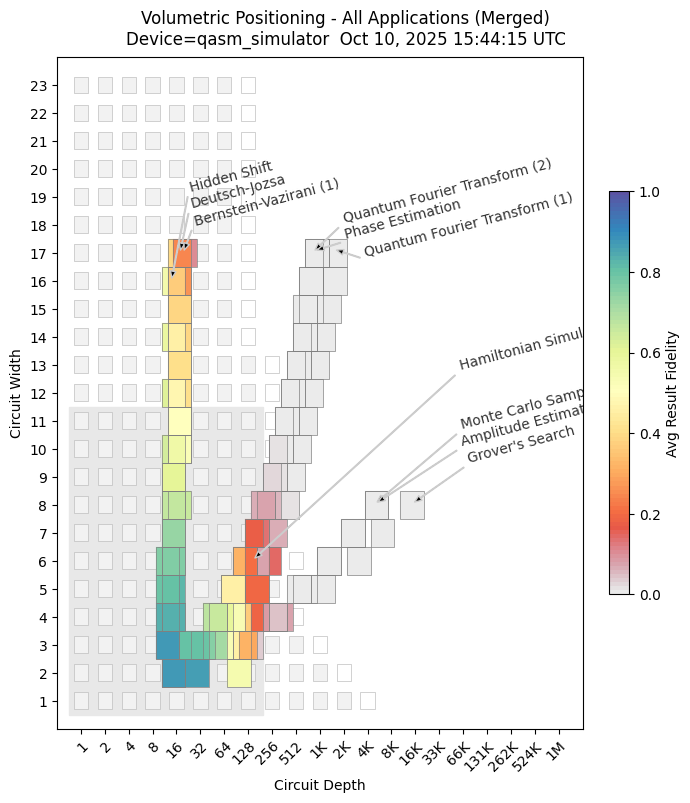

In [23]:
import sys
sys.path.insert(1, "_common")
import metrics

# metrics.depth_base = 2
# metrics.QV = 0
# apps = [ "Hidden Shift", "Grover's Search", "Quantum Fourier Transform (1)", "Hamiltonian Simulation" ]
# backend_id='qasm_simulator'

metrics.plot_all_app_metrics(backend_id, do_all_plots=False, include_apps=None)